In [19]:
import numpy as np
import numpy.ma as ma
from astropy.coordinates import SkyCoord, Distance
from astropy import units as u
from astropy.cosmology import LambdaCDM as LCDM


In [2]:
SkyCoord(100*u.deg, 10*u.deg, distance = Distance(z = 8.2))

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, Mpc)
    (100., 10., 84544.59641025)>

In [4]:
cosmo = LCDM(H0=71, Om0=0.26, Ode0=0.74, Ob0=0.0435)
cosmo.comoving_distance(8.2)

<Quantity 9328.66507744 Mpc>

In [7]:
z = np.array([3.5,6, 7.2, 8.2])
np.array(cosmo.comoving_distance(z))

array([6997.40995112, 8531.43460448, 9006.00341076, 9328.66507744])

In [9]:
ra = np.array([10, 100, 32])
dec = np.array([2, 87, 23])
z = np.array([5.2, 5.1, 5.8])
cords = SkyCoord(ra*u.deg, dec*u.deg, cosmo.comoving_distance(z))

In [26]:
a = np.array([1,2,3,4,5,6])
a = ma.array(a)
pos = np.where(a > 3)
a[pos] = ma.masked
a

masked_array(data=[1, 2, 3, --, --, --],
             mask=[False, False, False,  True,  True,  True],
       fill_value=999999)

In [25]:
ma.array(a)

masked_array(data=[1, 2, 3, 0, 0, 0],
             mask=False,
       fill_value=999999)

In [1]:
import numpy as np

np.log1p(10)

2.3978952727983707

In [3]:
np.log(10+1)

2.3978952727983707

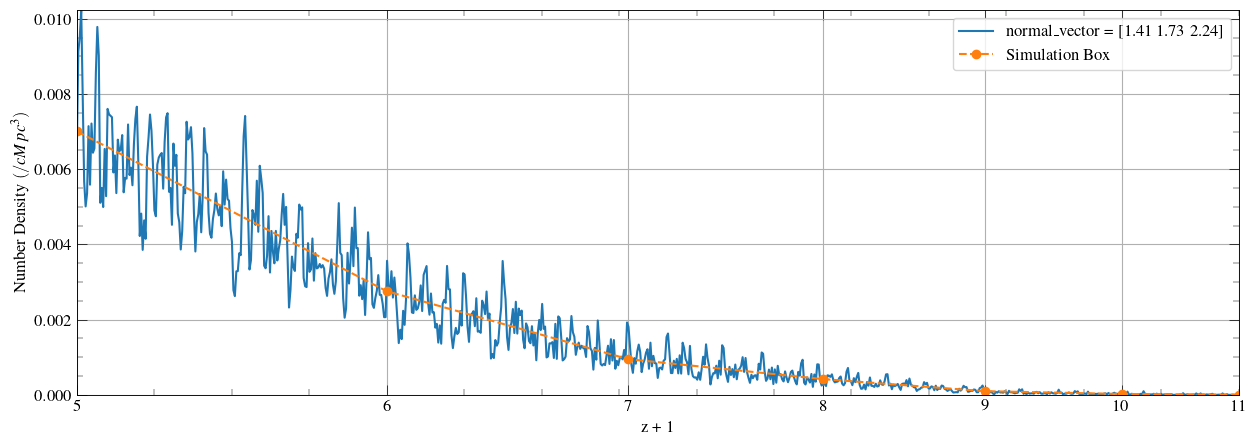

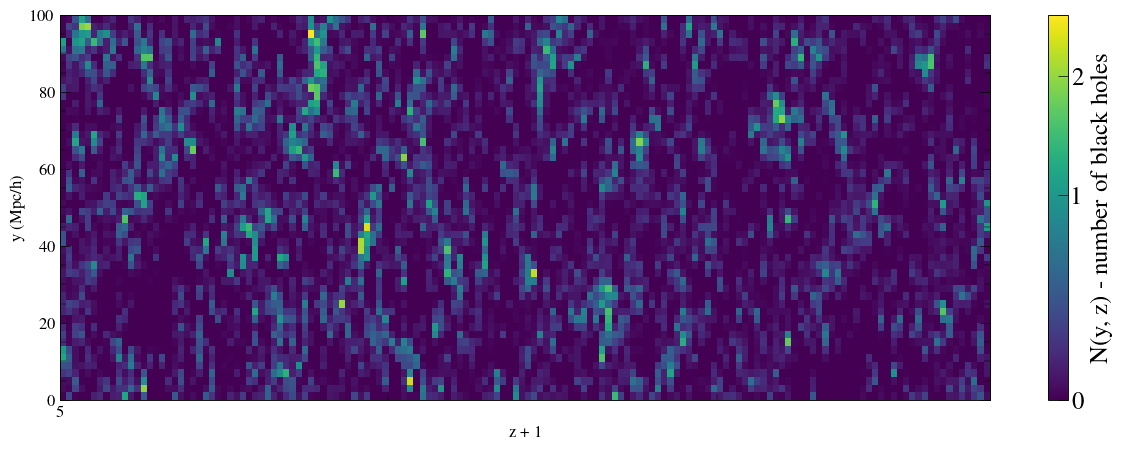

In [21]:
# 1) Load the 7 files which contains MBII black holes details in slices centered at 4, 5, 6, 7, 8, 9, 10 redshifts.
# 2) Extract the x, y, and z coordinates of the black holes.
# 3) Define the number of pixels in each dimension (50, 50, 1). and pixelated the data.
# 4) store each array which is n(x,y) for each redshift in a list called nz_arrays.


import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM
# Import the LogNorm object
from matplotlib.colors import LogNorm

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

nz_arrays = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

BH_density = []

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension
x_range = (0, 100000) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100000) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100000) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]
    bh_lum = data[:, 8]

    # Find the black hole number density
    BH_density.append(len(data[:, 0]))

    # I want to introduce luminosity cuts at this point
    bh_lum_sol = bh_lum * 1.472 * 10 ** 12 # 1 M0/yr * 0.1 * c^2 equvialent to 1.472 x 10^12 L0

    # now get the indices of the black holes that are within the luminosity range
    ind_lum = np.where((bh_lum_sol >= min_lum) & (bh_lum_sol < max_lum))[0]

    x_coordinates = x_coordinates[ind_lum]
    y_coordinates = y_coordinates[ind_lum]
    z_coordinates = z_coordinates[ind_lum]   
    
    # Calculate the pixel indices for each coordinate
    pixel_indices_x = ((x_coordinates - x_range[0]) / pixel_size_x).astype(int)
    pixel_indices_y = ((y_coordinates - y_range[0]) / pixel_size_y).astype(int)
    pixel_indices_z = ((z_coordinates - z_range[0]) / pixel_size_z).astype(int)
    
    # Create an empty n(x, y, z) array
    n_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    L_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    
    # Count the number of particles in each pixel
    for i in range(len(x_coordinates)):
        n_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += 1
        L_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += bh_lum_sol[i]
    
    nz_arrays.append(n_array)

# Divide by the volume of the simulation box to get the number density
BH_density = np.array(BH_density) / (100**3)

# Remove the h^3 factor from the number density
BH_density = BH_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h    

# Now each array in nz_arrays contains the n(x, y, z) for each redshift slice centered at 4, 5, 6, 7, 8, 9, 10.

# First convert the redshifts to comoving distances

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# These are the slice centers in the z direction for each redshift slice.

# Now I want to interpolate the data in nz_arrays to get the n(x, y, z) for any comoving distance in the range of new_z_axis.
sim_evolv_linear = interp1d(new_z_axis, nz_arrays, axis=0)

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

# Now I want to make another 3d array which contains the n(x, y, z) for each comoving distance in the range of new_z_axis.
# Define the new z axis which has the resolution of the simulation box.

new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Create an empty 3d array with shape same as the simulation along x and y
# and the length of the new z axis.

Lightcone = np.zeros((num_pixels_x, num_pixels_y, len(new_z_axis)))

# Now we need to fill the Lightcone array with the data from sim_evolv_linear, where when we move 1 comoving distance in the 
# z direction of the Lightcone array, we move 1 comoving distance in direction chosen at the start in the sim_evolv_linear array.

# We need a function of the following nature:
# Inputs: a

# This funcition finds the started plane of the simulation box given a normal vector and a center point.

from scipy.ndimage import map_coordinates

def create_rotated_plane(normal_vector, plane_center, num_pixels_plane):
    """
    Extract a 2D plane from a 3D array that makes an arbitrary angle with the axes.
    
    Parameters:
    array_3d (ndarray): The input 3D array.
    normal_vector (ndarray): A 3D vector normal to the plane.
    plane_center (ndarray): A 3D point representing the center of the plane.
    plane_size (tuple): The size of the plane in the form (width, height).
    plane_resolution (tuple): The resolution of the plane grid in the form (num_points_x, num_points_y).
    
    Returns:
    ndarray: A 2D array representing the extracted plane.
    """
    # Normalize the normal vector
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Create a grid of points in the plane
    x_size, y_size = num_pixels_plane
    x = np.arange(0, x_size)
    y = np.arange(0, y_size)
    xv, yv = np.meshgrid(x, y)
    
    # Create the plane basis vectors
    if np.all(normal_vector == [0, 0, 1]):
        u = np.array([1, 0, 0])
        v = np.array([0, 1, 0])
    else:
        u = np.cross(normal_vector, [0, 0, 1])
        u = u / np.linalg.norm(u)
        v = np.cross(normal_vector, u)
    
    # Transform plane points to 3D coordinates
    plane_points = plane_center[:, np.newaxis, np.newaxis] + u[:, np.newaxis, np.newaxis] * xv + v[:, np.newaxis, np.newaxis] * yv

    return plane_points

def trans_plane_points(normal_vector, plane_points):
    # This function transforms the plane points to the new plane points, translated alonged the normal vector by delattr.
    # Define the new plane points
    new_plane_points = plane_points + normal_vector[:, np.newaxis, np.newaxis]

    return new_plane_points

# calculate the volume of one slice z plane of the lightcone
volume = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * pixel_size_z

# Define the normal vector and center point of the plane
normal_vector = np.array([np.sqrt(2), np.sqrt(3), np.sqrt(5)]) #np.array([np.cos(np.radians(15)), np.sin(np.radians(15)), 0.1])

# Define the center point of the plane
plane_center = np.array([20, 10, 5])

plane_size = (x_range[1], y_range[1])
plane_resolution = (pixel_size_x, pixel_size_y)

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')

# Define the figure size
plt.figure(figsize=(15, 5))

# Create the plane points
plane_points = create_rotated_plane(normal_vector, plane_center, num_pixels_plane=(num_pixels_x, num_pixels_y))

# Find the values from the simulation box corresponding to the plane.
# grid wrap is used to apply periodic boundary conditions
for i, r in enumerate(new_z_axis):
        # print(np.shape(plane_points))
        Lightcone[:,:,i] = map_coordinates(sim_evolv_linear(r), plane_points, order=1, mode='grid-wrap')

        # move the plane points along the normal vector by pixel_size_z.
        plane_points = trans_plane_points(normal_vector, plane_points)

# Calculate the number density on lightcone
number_density = np.sum(Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
number_density = number_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h

# Plot the number density as a function of redshift
plt.plot(new_z_axis, number_density, label='normal_vector = {}'.format(np.round(normal_vector, 2)))

# Calculate the number density on lightcone
number_density = np.sum(Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
number_density = number_density * h**3

# Plot the BH density as a function of redshift with points
plt.plot(red_com, BH_density, 'o--', label='Simulation Box')

plt.ylabel(r"Number Density $(/cMpc^3)$")
# plt.title('Number Density as a Function of Redshift')
plt.legend()
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')

# Save the figure to the plots directory
plt.savefig(PLOT_DIRECTORY + 'NumberDensityLightcone.pdf')

plt.show()

# sum over the x axis to get the 2d projection of the lightcone.
Lightcone_2d = np.average(Lightcone[25:30,:,:], axis=0) #np.sum(Lightcone, axis=0)

# Plot the 2d projection of the lightcone
# figure size

#-----

plt.style.use('MNRAS_Style.mplstyle')
fig, ax = plt.subplots(figsize=(15, 5))

# increase the font size
plt.rcParams.update({'font.size': 18})

# Get the minimum and maximum values of the data
vmin = np.min(1 + Lightcone_2d)
vmax = np.max(1 + Lightcone_2d)

# Plot the data with imshow
cax = ax.imshow(1 + Lightcone_2d, origin='lower', cmap='viridis', extent=[new_z_axis[0], new_z_axis[-1], x_range[0], x_range[1]], norm=LogNorm(vmin=vmin, vmax=vmax))

ax.set_xlabel('z (Mpc/h)')
ax.set_ylabel('y (Mpc/h)')

# modify the color bar ticks by adding -1 to each tick

# Create the colorbar
cbar = fig.colorbar(cax, ticks=[1, 2, 3])
cbar.ax.set_yticklabels([0, 1, 2])
cbar.set_label('N(y, z) - number of black holes')

# Set the colorbar ticks to show N instead of 1 + N
# Get the current ticks
# ticks = cbar.get_ticks()

# # Subtract 1 from each tick to show N instead of 1 + N
# cbar.set_ticks(ticks)
# cbar.set_ticklabels([int(t - 1) for t in ticks])

# make the plot square
plt.gca().set_aspect('auto')
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')

# Getting the box aspect ratio of the plot, so that the we can determine the x limit inorder to make the pixels square.

plt.xlim(red_com[0], red_com[0] + 300)
plt.grid(visible=False)

# Save the figure to a pdf file
plt.savefig(PLOT_DIRECTORY + 'Lightcone2d.pdf')

plt.show()

# # Apply the transformation log(1 + N) to the data
# Lightcone_transformed = np.log1p(Lightcone_2d)

# plt.style.use('MNRAS_Style.mplstyle')
# plt.figure(figsize=(14, 5))

# # Increase the font size
# plt.rcParams.update({'font.size': 18})

# print(Lightcone_2d.min(), Lightcone_2d.max())
# print(Lightcone_transformed.min(), Lightcone_transformed.max())

# # Create a LogNorm object for the normalization
# norm = LogNorm(vmin=Lightcone_transformed.min(), vmax=Lightcone_transformed.max())

# plt.imshow(Lightcone_transformed, origin='lower', cmap='viridis', extent=[new_z_axis[0], new_z_axis[-1], x_range[0], x_range[1]], norm=norm)
# plt.xlabel('z (Mpc/h)')
# plt.ylabel('y (Mpc/h)')

# # Give label to colorbar
# cbar = plt.colorbar()
# cbar.set_label('log(1 + N(y, z)) - number of black holes')

# # Make the plot square
# plt.gca().set_aspect('auto')

# # Convert redshifts to comoving distances
# red_com = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# # Remove the xticks and xticklabels
# plt.xticks([])

# # Now add the redcom values as xticks
# plt.xticks(red_com, redshifts + 1)
# plt.xlabel('z + 1')

# # Save the figure to a pdf file
# plt.savefig(PLOT_DIRECTORY + 'Lightcone2d.pdf')

# plt.show()

#---

# Making the catalog of the lightcone
# Define the number of black holes in each pixel
n_bh = np.copy(Lightcone)

# Initialize an empty list to store the black hole coordinates
bh_coordinates = []

# Calculate the number of slices
new_num_slices = len(new_z_axis)

# Define the pixel centers
pixel_centers_x = np.linspace(x_range[0] + pixel_size_x / 2, x_range[1] - pixel_size_x / 2, num_pixels_x)
pixel_centers_y = np.linspace(y_range[0] + pixel_size_y / 2, y_range[1] - pixel_size_y / 2, num_pixels_y)
pixel_centers_z = np.copy(new_z_axis)

# Iterate over the pixels and distribute the black holes
for k in range(new_num_slices):
    for i in range(num_pixels_x):
        for j in range(num_pixels_y):
            # Get the number of black holes in the current pixel
            n = round(n_bh[i, j, k])
            
            # Generate random x, y, z coordinates for the black holes in the pixel
            x_coords = np.random.uniform(low=pixel_centers_x[i] - pixel_size_x / 2, high=pixel_centers_x[i] + pixel_size_x / 2, size=n)
            y_coords = np.random.uniform(low=pixel_centers_y[j] - pixel_size_y / 2, high=pixel_centers_y[j] + pixel_size_y / 2, size=n)
            z_coords = np.random.uniform(low=pixel_centers_z[k] - pixel_size_z / 2, high=pixel_centers_z[k] + pixel_size_z / 2, size=n)
            
            # Append the coordinates to the list
            bh_coordinates.extend(list(zip(x_coords, y_coords, z_coords)))

# Convert the list of coordinates to a numpy array
bh_coordinates = np.array(bh_coordinates)

# This concludes the production of the light cone. bh_coordinates now consists of the x, y, z coordinates of the black holes in the light cone, extrapolated
# from the MBII data.

# Now I want to save the bh_coordinates to a file in the data directory so that I can use it in the future.
# I want to save the numpy array to a file using np.save() function.

# Save the bh_coordinates to a file
np.save(DATA_DIRECTORY + 'bh_coordinates_lightcone_v3.npy', bh_coordinates)

In [6]:
tempa = 1e9

# Convert the number to scientific notation and replace 'e+' with 'e'
formatted_tempa = "{:.0e}".format(tempa).replace('e+0', 'e').replace('e+','e')

print("This is how this will show {}".format(formatted_tempa))

This is how this will show 1e9


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM
# Import the LogNorm object
from matplotlib.colors import LogNorm

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# Define the minimum luminosity
min_lum = 1e9
formatted_min_lum = "{:.0e}".format(min_lum).replace('e+0', 'e').replace('e+','e')

# Read the light cone file
Lightcone_original = np.load(DATA_DIRECTORY + 'Lightcone_lumcut{}.npy'.format(formatted_min_lum))

# Read the coordinates from the light cone file
Lightcone_point_dist = np.load(DATA_DIRECTORY + 'bh_coordinates_lightcone_lumcut{}_v3.npy'.format(formatted_min_lum))

# Read the x, y, z coordinates from the light cone file
x_coordinates = Lightcone_point_dist[:,0]
y_coordinates = Lightcone_point_dist[:,1]
z_coordinates = Lightcone_point_dist[:,2]

# Define the number of pixels in each dimension of 100 Mpch^-1 box
num_pixels_x = 50
num_pixels_y = 50

# Calculate the pixel size in each dimension
x_range = (0, 100)
y_range = (0, 100)

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = pixel_size_x

# Find the number of pixels in the z direction
new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)
num_pixels_z = len(new_z_axis)

# Define the new z range
z_range = (new_z_axis[0] - pixel_size_z/2, new_z_axis[-1] + pixel_size_z/2) #When drawing black holes position from pixelated lightcone, this is the range
                                                                            #used.
# Calculate the pixel indices for each coordinate
pixel_indices_x = ((x_coordinates - x_range[0]) / pixel_size_x).astype(int)
pixel_indices_y = ((y_coordinates - y_range[0]) / pixel_size_y).astype(int)
pixel_indices_z = ((z_coordinates - z_range[0]) / pixel_size_z).astype(int)

# Create an empty n(x, y, z) array
Lightcone = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))

# Count the number of particles in each pixel
for i in range(len(x_coordinates)):
    Lightcone[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += 1

(0.0, 2.0)

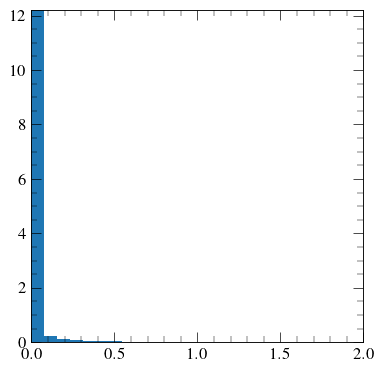

In [17]:
# Define the style of the plot
plt.style.use('MNRAS_Style.mplstyle')
plt.grid(visible=False)

# Make a histogram of the lightcone
hist_data = plt.hist(Lightcone_original.flatten(), bins=100, density=True, label='Original Lightcone');

# Make the plot box square
plt.gca().set_box_aspect(1)

plt.xlim(0, 2)

In [23]:
Lightcone == np.asarray(Lightcone_original, dtype=int)

array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  Tr

In [24]:
# Check if the two arrays, Lightcone_original and Lightcone_point_dist are equal
np.all(Lightcone == np.asarray(Lightcone_original, dtype=int))

False

In [27]:
len(np.where(Lightcone != np.asarray(Lightcone_original, dtype=int))[0])

14518